## import library

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

### Load data

In [33]:
df = pd.read_csv('../data/processed/data_kriminal_processed_full.csv')
df.head()

,NO_LAPORAN,TGL_LAPORAN,PERKARA,TKP,PELAPOR,TERLAPOR,MO,BARANG BUKTI,PROSES,DESA,KET,MO_clean,MO_casefold,MO_normalized,MO_tokens,MO_stopwords,MO_tokens_stemmed,MO_final_text
0,LP/B/01/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,1 Januari 2021,Penganiayaan,"Dusun Melati, Sungai Purun Kecil, Kec. Sungai ...",EMIL PERMATA,LIE,Pelaku merasa tersinggung dengan tatapan korba...,Hasil Visum et Repertum,Sidik,Sungai Purun Kecil,Tipiring Sidang PN,Pelaku merasa tersinggung dengan tatapan korba...,pelaku merasa tersinggung dengan tatapan korba...,pelaku merasa tersinggung dengan tatapan korba...,"['pelaku', 'merasa', 'tersinggung', 'dengan', ...","['pelaku', 'tersinggung', 'tatapan', 'korban',...","['pelaku', 'singgung', 'tatap', 'korban', 'pap...",pelaku singgung tatap korban papas jalan pukul...
1,LP/B/02/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,1 Januari 2021,Pencurian,"Gg. Usaha RT 20/RW 09, Sungai Batang, Kec. Sun...",DINI,PASARIBU,"Pelaku berpura-pura menjadi tamu/pembeli, saat...",Perhiasan emas,Sidik,Sungai Batang,P.21 Tahap II,Pelaku berpura pura menjadi tamu pembeli saat ...,pelaku berpura pura menjadi tamu pembeli saat ...,pelaku berpura pura menjadi tamu pembeli saat ...,"['pelaku', 'berpura', 'pura', 'menjadi', 'tamu...","['pelaku', 'berpura', 'pura', 'tamu', 'pembeli...","['pelaku', 'pura', 'pura', 'tamu', 'pembeli', ...",pelaku pura pura tamu pembeli korban lengah pe...
2,LP/B/03/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,4 Januari 2021,Pencurian,"Jl. Raya Nusapati RT 09/RW 05, Sungai Purun Ke...",ALFIN LIANG,FIKA,"Pelaku berpura-pura menjadi tamu/pembeli, saat...",1 buah HP,Sidik,Sungai Purun Kecil,Tahap I,Pelaku berpura pura menjadi tamu pembeli saat ...,pelaku berpura pura menjadi tamu pembeli saat ...,pelaku berpura pura menjadi tamu pembeli saat ...,"['pelaku', 'berpura', 'pura', 'menjadi', 'tamu...","['pelaku', 'berpura', 'pura', 'tamu', 'pembeli...","['pelaku', 'pura', 'pura', 'tamu', 'pembeli', ...",pelaku pura pura tamu pembeli korban lengah pe...
3,LP/B/04/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,5 Januari 2021,Narkoba,"Dusun Sejahtera, Sungai Batang, Kec. Sungai Pi...",LESTARI IRAWAN,MANSUR FAJAR,Petugas mencurigai gerak-gerik pelaku di pingg...,Timbangan digital,Dalam Lidik,Sungai Batang,Dalam Lidik,Petugas mencurigai gerak gerik pelaku di pingg...,petugas mencurigai gerak gerik pelaku di pingg...,petugas mencurigai gerak gerik pelaku di pingg...,"['petugas', 'mencurigai', 'gerak', 'gerik', 'p...","['petugas', 'mencurigai', 'gerak', 'gerik', 'p...","['petugas', 'curiga', 'gerak', 'gerik', 'pelak...",petugas curiga gerak gerik pelaku pinggir jala...
4,LP/B/05/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,5 Januari 2021,Narkoba,"Gg. Famili, Desa/Kel. Peniraman, Kec. Sungai P...",EKO YASIN NG,DADANG KARIM,Petugas mencurigai gerak-gerik pelaku di pingg...,Paket klip sabu,Sidik,Peniraman,P.21 Tahap II,Petugas mencurigai gerak gerik pelaku di pingg...,petugas mencurigai gerak gerik pelaku di pingg...,petugas mencurigai gerak gerik pelaku di pingg...,"['petugas', 'mencurigai', 'gerak', 'gerik', 'p...","['petugas', 'mencurigai', 'gerak', 'gerik', 'p...","['petugas', 'curiga', 'gerak', 'gerik', 'pelak...",petugas curiga gerak gerik pelaku pinggir jala...


### pilih fitur dan target

In [34]:
# Fitur dan target
X = df["MO_final_text"].fillna("")
y = df["PERKARA"]

Skenario A

pisahkan data berdasarkan :

-80% training

-20% testing

Gunakan stratify
Karena data tidak seimbang

In [35]:
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Skenario B

pisahkan data berdasarkan :

-70% training

-30% testing

Gunakan stratify
Karena data tidak seimbang

In [36]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

### Hitung TF-IDF

In [37]:
tfidf = TfidfVectorizer()

X_train_80_tfidf = tfidf.fit_transform(X_train_80)

X_test_20_tfidf = tfidf.transform(X_test_20)

In [38]:
tfidf = TfidfVectorizer()

X_train_70_tfidf = tfidf.fit_transform(X_train_70)

X_test_30_tfidf = tfidf.transform(X_test_30)

### Pemodelan Naive Bayes

In [39]:
nb_80 = MultinomialNB()

nb_80.fit(X_train_80_tfidf, y_train_80)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [40]:
nb_70 = MultinomialNB()

nb_70.fit(X_train_70_tfidf, y_train_70)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### Prediksi

In [41]:
y_pred_80 = nb_80.predict(
    X_test_20_tfidf
)

In [42]:
y_pred_70 = nb_70.predict(
    X_test_30_tfidf
)

### Evaluasi

Accuracy

In [43]:
acc_80 = accuracy_score(
    y_test_20,
    y_pred_80
)

print(acc_80)

0.9038461538461539


In [44]:
acc_70 = accuracy_score(
    y_test_30,
    y_pred_70
)

print(acc_70)

0.8846153846153846


Classification Report

In [45]:
print(
    classification_report(
        y_test_20,
        y_pred_80
    )
)

              precision    recall  f1-score   support

     Narkoba       1.00      0.70      0.82        10
   Pencurian       0.82      1.00      0.90        42
Penganiayaan       0.94      0.94      0.94        18
    Penipuan       1.00      0.88      0.94        17
   Perusakan       1.00      0.76      0.87        17

    accuracy                           0.90       104
   macro avg       0.95      0.86      0.90       104
weighted avg       0.92      0.90      0.90       104



In [46]:
print(
    classification_report(
        y_test_30,
        y_pred_70
    )
)

              precision    recall  f1-score   support

     Narkoba       1.00      0.62      0.77        16
   Pencurian       0.80      1.00      0.89        63
Penganiayaan       0.93      0.96      0.95        27
    Penipuan       1.00      0.88      0.94        25
   Perusakan       1.00      0.68      0.81        25

    accuracy                           0.88       156
   macro avg       0.95      0.83      0.87       156
weighted avg       0.91      0.88      0.88       156



Confusion Matrix

In [47]:
cm_80 = confusion_matrix(
    y_test_20,
    y_pred_80
)

print(cm_80)

[[ 7  3  0  0  0]
 [ 0 42  0  0  0]
 [ 0  1 17  0  0]
 [ 0  1  1 15  0]
 [ 0  4  0  0 13]]


In [48]:
cm_70 = confusion_matrix(
    y_test_30,
    y_pred_70
)

print(cm_70)

[[10  6  0  0  0]
 [ 0 63  0  0  0]
 [ 0  1 26  0  0]
 [ 0  2  1 22  0]
 [ 0  7  1  0 17]]


### Visualisasi Confusion Matrix

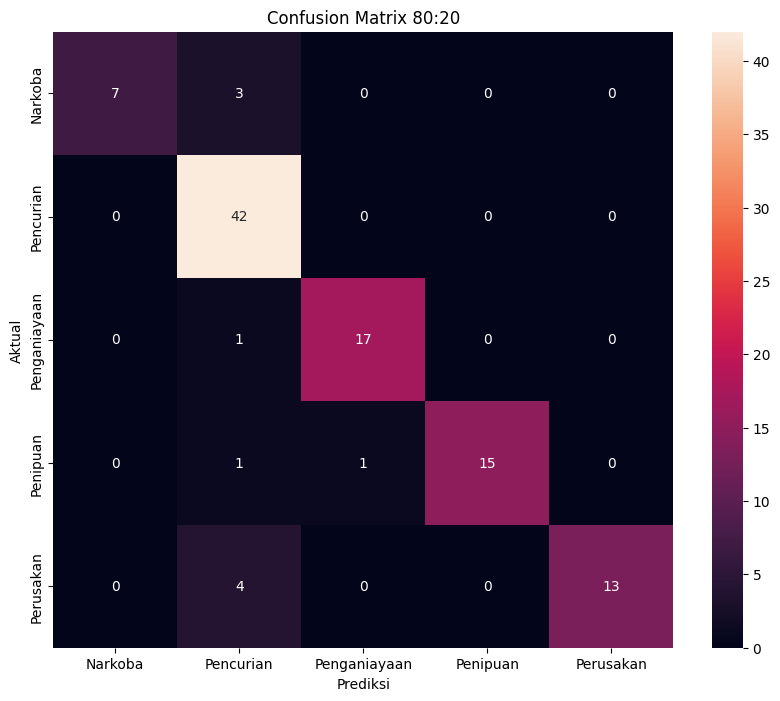

In [49]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_80,
    annot=True,
    fmt='d',
    xticklabels=nb_80.classes_,
    yticklabels=nb_80.classes_
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix 80:20')

plt.show()

Berdasarkan hasil pengujian menggunakan algoritma Multinomial Naive Bayes dengan skenario pembagian data 80:20, diperoleh nilai akurasi sebesar 90,38%. Hasil ini menunjukkan bahwa model mampu mengklasifikasikan jenis perkara kriminal dengan tingkat ketepatan yang tinggi.

Nilai precision, recall, dan F1-score menunjukkan bahwa sebagian besar kelas berhasil dikenali dengan baik oleh model. Kelas Penganiayaan dan Penipuan memiliki performa yang sangat baik dengan nilai F1-score masing-masing sebesar 0,94. Kelas Pencurian memperoleh nilai recall sebesar 1,00, yang berarti seluruh data Pencurian pada data uji berhasil diprediksi dengan benar oleh model.

Kelas Narkoba memperoleh nilai precision sebesar 1,00 dan recall sebesar 0,70. Hal ini menunjukkan bahwa seluruh prediksi Narkoba yang dihasilkan model benar, namun masih terdapat beberapa data Narkoba yang salah diklasifikasikan ke kelas lain. Sementara itu, kelas Perusakan memperoleh nilai precision sebesar 1,00 dan recall sebesar 0,76, yang menunjukkan bahwa sebagian kasus Perusakan masih memiliki kemiripan karakteristik dengan kelas Pencurian.

Secara keseluruhan, nilai Macro F1-score sebesar 0,90 menunjukkan bahwa model memiliki kemampuan yang baik dalam mengenali seluruh kelas secara seimbang tanpa terlalu dipengaruhi oleh jumlah data pada masing-masing kelas.


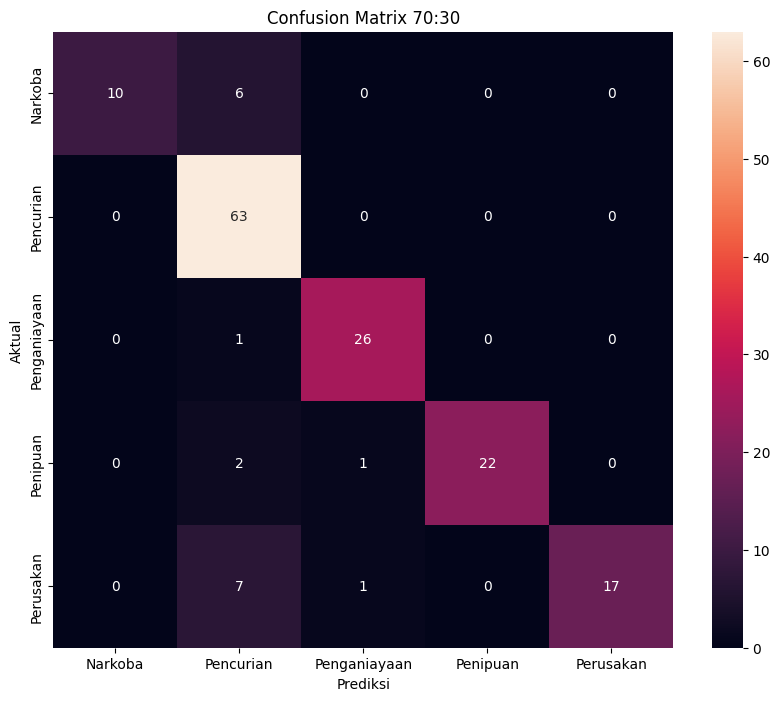

In [50]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_70,
    annot=True,
    fmt='d',
    xticklabels=nb_70.classes_,
    yticklabels=nb_70.classes_
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix 70:30')

plt.show()

Pada skenario pembagian data 70:30, model Multinomial Naive Bayes memperoleh nilai akurasi sebesar 88,46%. Hasil ini menunjukkan performa yang masih sangat baik meskipun sedikit lebih rendah dibandingkan skenario 80:20.

Nilai F1-score tertinggi diperoleh oleh kelas Penganiayaan sebesar 0,95 dan Penipuan sebesar 0,94. Kelas Pencurian juga menunjukkan performa yang sangat baik dengan nilai recall sebesar 1,00, yang berarti seluruh data Pencurian pada data uji berhasil dikenali oleh model.

Kelas Narkoba memperoleh nilai recall sebesar 0,62 sehingga masih terdapat beberapa data yang salah diklasifikasikan. Demikian pula pada kelas Perusakan yang memperoleh recall sebesar 0,68. Hal ini menunjukkan bahwa kedua kelas tersebut masih memiliki karakteristik teks yang mirip dengan kelas Pencurian.

Secara keseluruhan, nilai Macro F1-score sebesar 0,87 menunjukkan bahwa model tetap mampu memberikan performa klasifikasi yang baik pada seluruh kelas yang diuji.

### Kesimpulan Pemilihan Split
Berdasarkan hasil pengujian pada dua skenario pembagian data, yaitu 80:20 dan 70:30, diperoleh bahwa skenario 80:20 menghasilkan performa terbaik dengan nilai akurasi sebesar 90,38% dan Macro F1-score sebesar 0,90. Sementara itu, skenario 70:30 menghasilkan akurasi sebesar 88,46% dan Macro F1-score sebesar 0,87.

Perbedaan performa tersebut menunjukkan bahwa jumlah data latih yang lebih besar pada skenario 80:20 memberikan kemampuan pembelajaran yang lebih baik bagi model dalam mengenali pola kata pada masing-masing jenis perkara kriminal. Oleh karena itu, skenario pembagian data 80:20 dipilih sebagai skenario terbaik dan digunakan pada tahap optimasi model selanjutnya.


# parameter tuning jika diperlukan

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

In [52]:
nb_tuned = MultinomialNB()

param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1, 2, 5]
}

grid = GridSearchCV(
    estimator=nb_tuned,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(
    X_train_80_tfidf,
    y_train_80
)

,estimator,MultinomialNB()
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [53]:
print(grid.best_params_)
print(grid.best_score_)

{'alpha': 0.1}
0.9478312487452438


In [54]:
best_nb = grid.best_estimator_

In [55]:
y_pred_tuned = best_nb.predict(
    X_test_20_tfidf
)

In [56]:
print(
    classification_report(
        y_test_20,
        y_pred_tuned
    )
)

              precision    recall  f1-score   support

     Narkoba       1.00      1.00      1.00        10
   Pencurian       0.98      1.00      0.99        42
Penganiayaan       0.95      1.00      0.97        18
    Penipuan       1.00      0.94      0.97        17
   Perusakan       1.00      0.94      0.97        17

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104



In [57]:
acc_80_tuned = accuracy_score(
    y_test_20,
    y_pred_tuned
)

print("Accuracy 80:20 (Tuned):", acc_80_tuned)

Accuracy 80:20 (Tuned): 0.9807692307692307


In [58]:
cm_80_tuned = confusion_matrix(
    y_test_20,
    y_pred_tuned
)

print(cm_80_tuned)

[[10  0  0  0  0]
 [ 0 42  0  0  0]
 [ 0  0 18  0  0]
 [ 0  0  1 16  0]
 [ 0  1  0  0 16]]


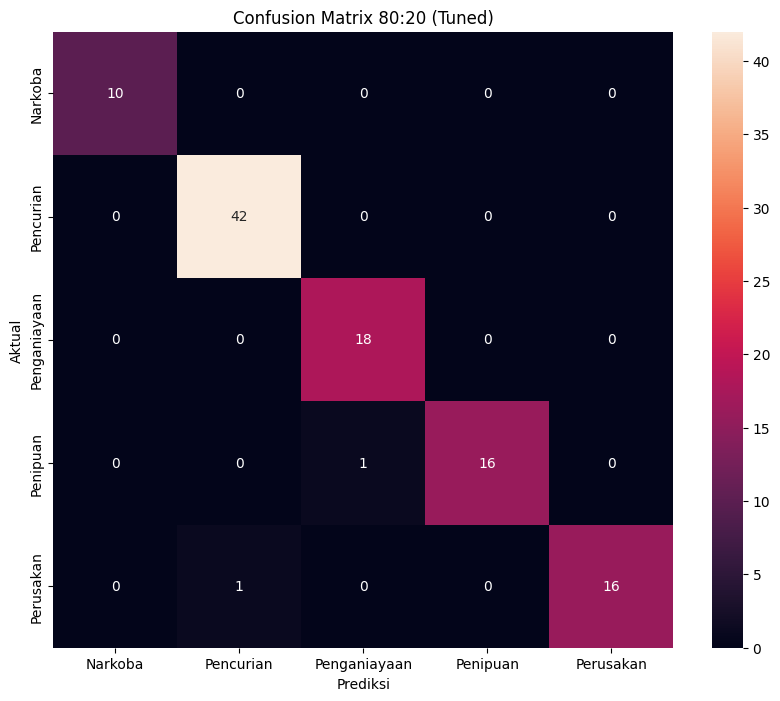

In [59]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm_80_tuned,
    annot=True,
    fmt='d',
    xticklabels=best_nb.classes_,
    yticklabels=best_nb.classes_
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix 80:20 (Tuned)')

plt.show()

### hasil Grid Search

In [60]:
cv_results = pd.DataFrame(
    grid.cv_results_
)

cv_results[
    ['param_alpha',
     'mean_test_score',
     'rank_test_score']
].sort_values(
    'rank_test_score'
)

,param_alpha,mean_test_score,rank_test_score
1,0.10,0.947831,1
0,0.01,0.946890,2
2,0.50,0.937928,3
3,1.00,0.862233,4
4,2.00,0.653292,5
5,5.00,0.293296,6


Berdasarkan hasil pengujian, optimasi hyperparameter pada algoritma Multinomial Naive Bayes menggunakan metode Grid Search Cross Validation berhasil meningkatkan performa klasifikasi. Proses tuning dilakukan dengan menguji beberapa nilai parameter alpha, yaitu 0.01, 0.1, 0.5, 1, 2, dan 5. Hasil optimasi menunjukkan bahwa nilai alpha terbaik adalah 0.1 dengan nilai rata-rata Macro F1-score sebesar 0.9478 pada proses validasi silang 5-fold.

Perbandingan performa menunjukkan bahwa model baseline pada skenario pembagian data 80:20 memperoleh akurasi sebesar 90,38%, sedangkan model hasil tuning mencapai akurasi sebesar 98,08%. Selain itu, nilai Macro F1-score meningkat dari 0,90 menjadi 0,98. Peningkatan tersebut menunjukkan bahwa optimasi hyperparameter mampu meningkatkan kemampuan model dalam mengenali pola pada setiap jenis perkara kriminal secara lebih akurat.

Hasil evaluasi menunjukkan bahwa hampir seluruh kelas mengalami peningkatan performa setelah dilakukan tuning. Kelas Narkoba yang sebelumnya memiliki nilai recall sebesar 0,70 meningkat menjadi 1,00 sehingga seluruh data Narkoba pada data uji berhasil diklasifikasikan dengan benar. Kelas Perusakan mengalami peningkatan recall dari 0,76 menjadi 0,94, sedangkan kelas Penganiayaan meningkat dari 0,94 menjadi 1,00. Kelas Pencurian tetap mempertahankan performa yang sangat tinggi dengan nilai F1-score sebesar 0,99.

Berdasarkan confusion matrix, hanya terdapat dua kesalahan klasifikasi pada model hasil tuning, yaitu satu data Penipuan yang diprediksi sebagai Penganiayaan dan satu data Perusakan yang diprediksi sebagai Pencurian. Hal ini menunjukkan bahwa model hasil tuning memiliki kemampuan yang sangat baik dalam membedakan karakteristik teks antar jenis perkara kriminal.

Dengan demikian, model Multinomial Naive Bayes hasil tuning dengan nilai alpha sebesar 0.1 dipilih sebagai model terbaik karena memberikan performa klasifikasi tertinggi dibandingkan model baseline. Model ini memperoleh akurasi sebesar 98,08%, Macro Precision sebesar 0,98, Macro Recall sebesar 0,98, dan Macro F1-score sebesar 0,98 sehingga layak digunakan pada tahap implementasi sistem klasifikasi perkara kriminal.


### simpan model

In [61]:
joblib.dump(
    best_nb,
    '../data/models/naive_bayes_model.pkl'
)

['../data/models/naive_bayes_model.pkl']

In [62]:
joblib.dump(
    tfidf,
    '../data/models/tfidf_vectorizer.pkl'
)

['../data/models/tfidf_vectorizer.pkl']